# Домашнее задание №2: Разведочный анализ данных (EDA)
**Датасет:** [Netflix Movies and TV Shows](https://www.kaggle.com/datasets/shivamb/netflix-shows)
**Описание:** Данные содержат список фильмов и телешоу, доступных на Netflix по состоянию на 2021 год.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('netflix_titles.csv')

print(f"Размер датасета: {df.shape}")
display(df.head())

print("\n--- Общая информация ---")
df.info()

print("\n--- Статистика по категориальным признакам ---")
display(df.describe(include="str"))

print("--- Пропуски по колонкам ---")
print(df.isnull().sum())

duplicates_count = df.duplicated().sum()
print(f"\nКоличество полных дубликатов строк: {duplicates_count}")

print("\n--- Типы данных ---")
print(df.dtypes)

Размер датасета: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



--- Общая информация ---
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB

--- Статистика по категориальным признакам ---


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


--- Пропуски по колонкам ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Количество полных дубликатов строк: 0

--- Типы данных ---
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


# Пропуски и очистка

In [4]:
#Используем fillna так как при использовании dropna будет удалент много ценной информации
df['director'] = df['director'].fillna('No Director')
df['cast'] = df['cast'].fillna('No Cast')

#Пустое значение страны будем заполнять модой
country_mode = df['country'].mode()[0]
print(f"Самая частая страна (мода): {country_mode}")

df['country'] = df['country'].fillna(country_mode)

#Строки с мизерным по сравнению с размером датасета количесвтом пропусков можем удалить применив dropna
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

print("\n--- Пропуски после очистки ---")
print(df.isnull().sum())

Самая частая страна (мода): United States

--- Пропуски после очистки ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


# Расширенная статистика

In [5]:
#Из числовых характеристик у меня только год релиза
mean_val = df['release_year'].mean()
median_val = df['release_year'].median()
mode_val = df['release_year'].mode()[0]
min_val = df['release_year'].min()
max_val = df['release_year'].max()
percentiles = df['release_year'].quantile([0.05, 0.25, 0.50, 0.75, 0.95])

variance_val = df['release_year'].var()
skewness_val = df['release_year'].skew()
kurtosis_val = df['release_year'].kurt()

print("=== Расширенная статистика для release_year ===")
print(f"Минимум:          {min_val}")
print(f"Максимум:         {max_val}")
print(f"Среднее:          {mean_val:.2f}")
print(f"Медиана:          {median_val}")
print(f"Мода:             {mode_val}")
print("-" * 30)
print(f"Перцентиль 5%:    {percentiles[0.05]}")
print(f"Перцентиль 25%:   {percentiles[0.25]} (Q1)")
print(f"Перцентиль 50%:   {percentiles[0.50]} (Q2/Медиана)")
print(f"Перцентиль 75%:   {percentiles[0.75]} (Q3)")
print(f"Перцентиль 95%:   {percentiles[0.95]}")
print("-" * 30)
print(f"Дисперсия:        {variance_val:.2f}")
print(f"Асимметрия:       {skewness_val:.2f}")
print(f"Эксцесс:          {kurtosis_val:.2f}")

=== Расширенная статистика для release_year ===
Минимум:          1925
Максимум:         2021
Среднее:          2014.18
Медиана:          2017.0
Мода:             2018
------------------------------
Перцентиль 5%:    1997.0
Перцентиль 25%:   2013.0 (Q1)
Перцентиль 50%:   2017.0 (Q2/Медиана)
Перцентиль 75%:   2019.0 (Q3)
Перцентиль 95%:   2021.0
------------------------------
Дисперсия:        77.89
Асимметрия:       -3.45
Эксцесс:          16.22


**Дисперсия** показывает разбросанность данных относительно среднего. Исходя из моих данных можно понять что у нетфликса в датасете есть фильмы не только современный но и 40-ых и 50-ых годов, что и делает дисперсия достаточно большой. **Ассиметрия** показывает скошенность распределения, так как мы видим отрицательную ассиметрию то можно сделать вывод что она скошено влево и хвост уходит туда, то вполне логично для этого датасета. **Эксцесс** показывает остроту пика и тяжесть хвостов, то что у меня получился большой положительный эксцесс означает что огромное превалирующее число фильмов вышло окло среднего значения и очень резкое падение к хвостам наблюдается, если говорить про кинематограф это тоже является вполне логичным.

# Фичи: Энкодинг и Инжиниринг

In [8]:

from sklearn.preprocessing import LabelEncoder
from category_encoders import HashingEncoder


df_fe = df.copy()



# Фича 1: Год добавления и месяц
df_fe['date_added'] = pd.to_datetime(df_fe['date_added'].str.strip())
df_fe['year_added'] = df_fe['date_added'].dt.year
df_fe['month_added'] = df_fe['date_added'].dt.month

# Фича 2: "Возраст" контента на момент его выхода на Netflix
df_fe['years_to_netflix'] = df_fe['year_added'] - df_fe['release_year']

# Фича 3: Группировка редких категорий (Rating) в "Other"
# Оставляем топ-5 рейтингов, остальное — в Other
top_ratings = df_fe['rating'].value_counts().nlargest(5).index
df_fe['rating_grouped'] = df_fe['rating'].where(df_fe['rating'].isin(top_ratings), 'Other')




df_before = df_fe[['type', 'rating_grouped', 'country']].copy()

# А) One-Hot Encoding для 'type' (Movie/TV Show)
df_fe = pd.get_dummies(df_fe, columns=['type'], prefix='type')

# Б) Label Encoding для 'rating_grouped'
le = LabelEncoder()
df_fe['rating_label'] = le.fit_transform(df_fe['rating_grouped'].astype(str))




# Применяем хеширование к колонке 'country' (сжимаем в 8 признаков)
hasher = HashingEncoder(cols=['country'], n_components=8)
df_final = hasher.fit_transform(df_fe)


# --- ВЫВОД РЕЗУЛЬТАТОВ ---

print("=== СРАВНЕНИЕ ДО И ПОСЛЕ ===")
print("\n[ДО ЭНКОДИНГА]")
display(df_before.head())

print("\n[ПОСЛЕ ЭНКОДИНГА И ИНЖИНИРИНГА]")
# Выберем новые и измененные колонки для наглядности
output_cols = ['title', 'year_added', 'years_to_netflix', 'type_Movie', 'type_TV Show',
               'rating_label', 'col_0', 'col_1', 'col_2', 'col_3']
display(df_final[output_cols].head())

print(f"\nРазмерность данных до хеширования стран: {df_fe.shape}")
print(f"Размерность данных после хеширования стран: {df_final.shape}")

=== СРАВНЕНИЕ ДО И ПОСЛЕ ===

[ДО ЭНКОДИНГА]


,type,rating_grouped,country
0,Movie,PG-13,United States
1,TV Show,TV-MA,South Africa
2,TV Show,TV-MA,United States
3,TV Show,TV-MA,United States
4,TV Show,TV-MA,India



[ПОСЛЕ ЭНКОДИНГА И ИНЖИНИРИНГА]


,title,year_added,years_to_netflix,type_Movie,type_TV Show,rating_label,col_0,col_1,col_2,col_3
0,Dick Johnson Is Dead,2021,1,True,False,1,0,1,0,0
1,Blood & Water,2021,0,False,True,4,1,0,0,0
2,Ganglands,2021,0,False,True,4,0,1,0,0
3,Jailbirds New Orleans,2021,0,False,True,4,0,1,0,0
4,Kota Factory,2021,0,False,True,4,0,0,0,1



Размерность данных до хеширования стран: (8790, 18)
Размерность данных после хеширования стран: (8790, 25)


# Визуализация

C:\Users\viteb\AppData\Local\Temp\ipykernel_6100\1515224556.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index[:10], palette='viridis')


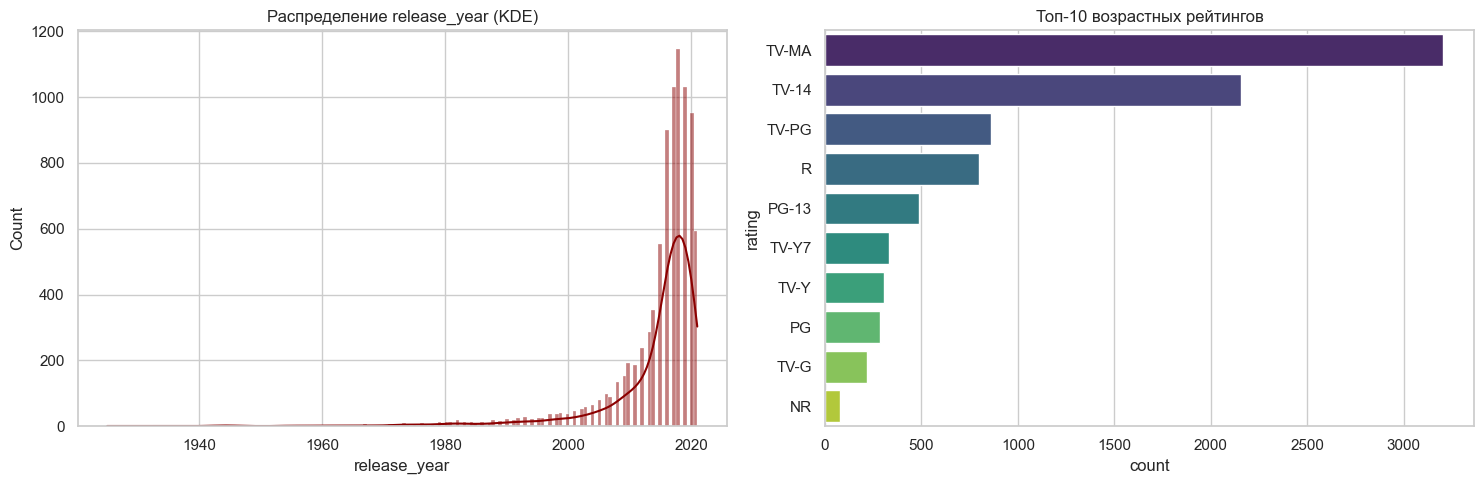

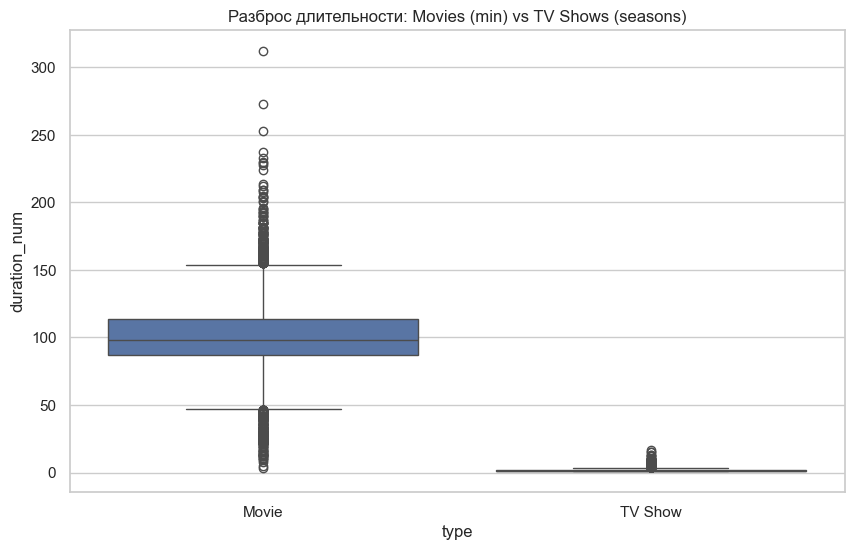

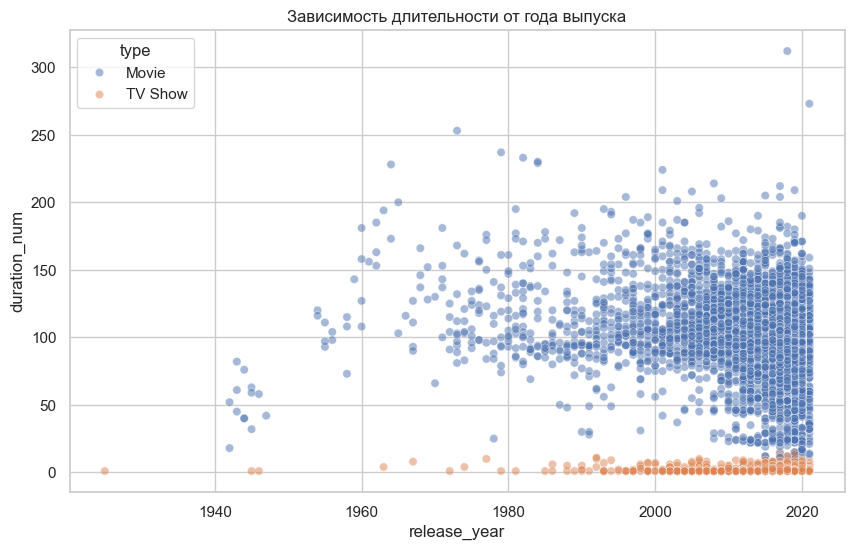

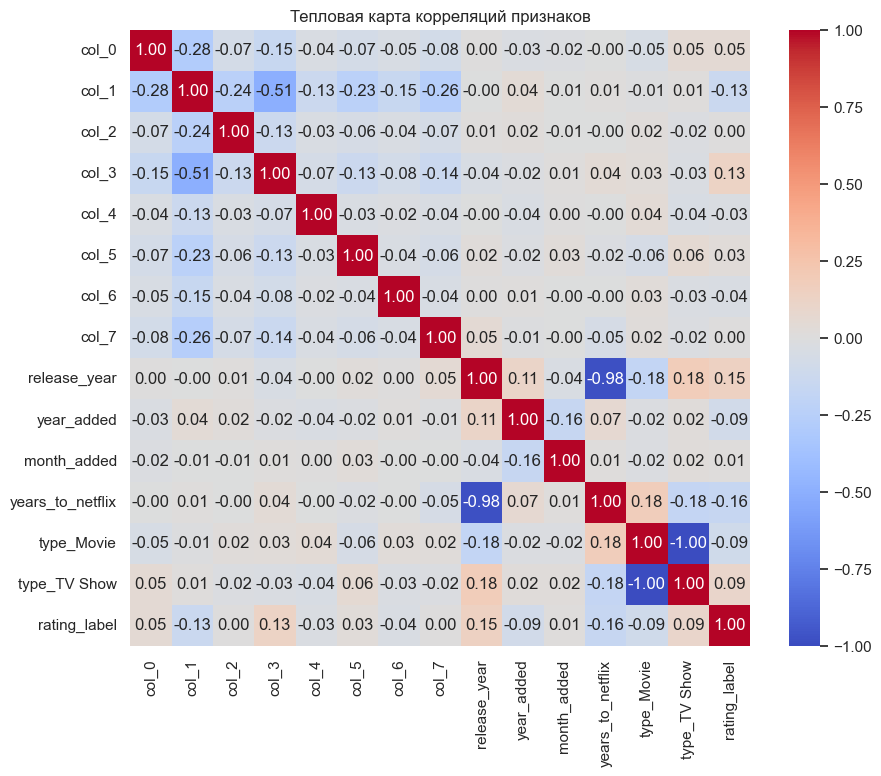

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Настройка общего стиля
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Левый график: Распределение лет (KDE + Histogram)
plt.subplot(1, 2, 1)
sns.histplot(df['release_year'], kde=True, color='darkred')
plt.title('Распределение release_year (KDE)')

# Правый график: Топ-10 рейтингов (Count Plot)
plt.subplot(1, 2, 2)
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index[:10], palette='viridis')
plt.title('Топ-10 возрастных рейтингов')

plt.tight_layout()
plt.show()

# Быстрая очистка duration для графиков
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

# Box Plot: Сравнение длительности по типу контента
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='duration_num', data=df)
plt.title('Разброс длительности: Movies (min) vs TV Shows (seasons)')
plt.show()

# Scatter Plot: Год выпуска vs Длительность (с помощью Seaborn)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='release_year', y='duration_num', hue='type', data=df, alpha=0.5)
plt.title('Зависимость длительности от года выпуска')

plt.figure(figsize=(10, 8))
# Считаем корреляцию только для числовых колонок
corr = df_final.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта корреляций признаков')
plt.show()

# Берем срез данных, чтобы график не тормозил
fig = px.scatter(df.head(1000),
                 x="release_year",
                 y="duration_num",
                 color="type",
                 hover_data=['title', 'country'],
                 title="Интерактивный анализ: Год vs Длительность (Первые 1000 записей)")

fig.show()

# Итоговые выводы
**Что я понял про датасет**: Исходя из этой работы можно понять что датасет Netflix это про здесь и сейчас, что подтверждает эксцесс и старые фильмы это скорее выбросы. Категории требуют укрупнения и добавления их в other что я и сделал. Так же можно сказать про неоднородность длительности, для фильмов используются минуты а для сериалов сезоны, что неудобно. Выбросы в фильмах — это либо классические киноэпопеи, либо записи концертов/интервью, в то время как выбросы в TV Shows (сериалы с 10+ сезонами) — это долгоиграющие франшизы. **Какие подсказки брал у AI и что в итоге проверял/дописывал руками»** руками написано все, кроме визуализации так как я ей никогда не пользовался разбирался по ходу. Общую информацию, пропуски и математическую часть было сделать несложно тем более после курса тервера, также спрашивал у AI про One hot encoding и label encoding, там писал 50/50 сам.